<a href="https://colab.research.google.com/github/echozhang77777/SKILL/blob/main/Copy_of_%E7%AC%AC%E5%85%AD%E8%AC%9B%EF%BC%9A%E8%A8%93%E7%B7%B4%E9%A1%9E%E7%A5%9E%E7%B6%93%E7%B6%B2%E8%B7%AF%E7%9A%84%E5%90%84%E7%A8%AE%E8%A8%A3%E7%AB%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 匯入必要的函式庫
import numpy as np
import matplotlib.pyplot as plt

## 需要用到的資料
#《機器學習 2021》相關資料
page_2021 = np.array([61, 29, 16, 21, 19, 9, 35, 43, 14, 60, 95 ,67, 38 ,39 ,42, 16, 64, 34, 37, 57]) #投影片頁數
duration_2021 = np.array([109, 51, 34, 31, 38,19 ,56, 74, 31, 93, 160, 99, 49, 76, 72, 35, 165, 68, 86, 78]) #課程時長(分鐘)

#《生成式人工智慧導論2024》相關資料
page_2024 =    np.array([27, 22, 27, 50, 49, 16, 24, 37, 33, 27, 36, 27, 36 ,30 ,16 ,41 ,62, 34  ]) #投影片頁數
word_2024 = np.array([ 2236, 1457,1309, 3404,2513,764,1448,2327,2006,1224,1121,1042,1040,1029, 1048,1946,2631,1846 ]) #投影片總字數
duration_2024 =    np.array([35, 30, 26, 35, 47 ,25, 35 ,38 ,37, 25, 38, 45, 46, 32, 15, 45 ,87, 38]) #課程時長(分鐘)

### 以《機器學習 2021》資料進行訓練

In [ ]:
#訓練資料
x1_train = page_2021 #函式輸入
y_train = duration_2021 #正確答案

# 定義 Loss (Mean Squared Error)
def mean_squared_error(y_pred, y_true):
    """
    Calculate Mean Squared Error
    y_pred: Model's predicted values (a vector)
    y_true: True label values (a vector)
    """
    return np.mean((y_pred - y_true)**2)

# 定義我們的模型 (線性模型)
def linear_model(x1, w, b):
    """
    線性模型的預測函式
    x1: 輸入特徵 (投影片頁數)
    w, b: 參數
    """
    return w * x1 + b

# --- 繪製 Loss Surface 準備---

# 建立範圍
w_range = np.linspace(0, 3, 100)
b_range = np.linspace(0, 20, 300)

w_range = np.linspace(0, 3, 100)
b_range = np.linspace(0, 20, 300)
W, B = np.meshgrid(w_range, b_range)

# 建立空的 Loss 矩陣
losses = np.zeros((len(b_range), len(w_range)))

# 逐一計算每個 (w, b) 的 loss
for i, b in enumerate(b_range):
    for j, w in enumerate(w_range):
        y_pred = linear_model(x1_train, w, b)
        loss = mean_squared_error(y_pred, y_train)
        losses[i, j] = loss

以一般的 Gradient Descent 來訓練模型

Epoch [1/100], Loss: 4593.2926, w: 2.9235, b: 15.0328
Epoch [2/100], Loss: 41751.1393, w: -3.0304, b: 14.9124
Epoch [3/100], Loss: 397813.2822, w: 15.4006, b: 15.2662
Epoch [4/100], Loss: 3809749.1932, w: -41.6531, b: 14.1522
Epoch [5/100], Loss: 36504340.1202, w: 134.9597, b: 17.5819
Epoch [6/100], Loss: 349797525.7073, w: -411.7534, b: 6.9463
Epoch [7/100], Loss: 3351903296.1592, w: 1280.6237, b: 39.8504
Epoch [8/100], Loss: 32119330968.1153, w: -3958.2102, b: -62.0245
Epoch [9/100], Loss: 307780802659.6974, w: 12258.8510, b: 253.3154
Epoch [10/100], Loss: 2949283819253.7881, w: -37941.8373, b: -722.8533
Epoch [11/100], Loss: 28261265736269.4570, w: 117456.7951, b: 2298.9050
Epoch [12/100], Loss: 270811217238284.8438, w: -363587.1053, b: -7055.1113
Epoch [13/100], Loss: 2595025858608659.0000, w: 1125507.3022, b: 21900.6749
Epoch [14/100], Loss: 24866618434521948.0000, w: -3484055.6752, b: -67733.3653
Epoch [15/100], Loss: 238282293148203776.0000, w: 10785067.0464, b: 209733.0756
Epoc

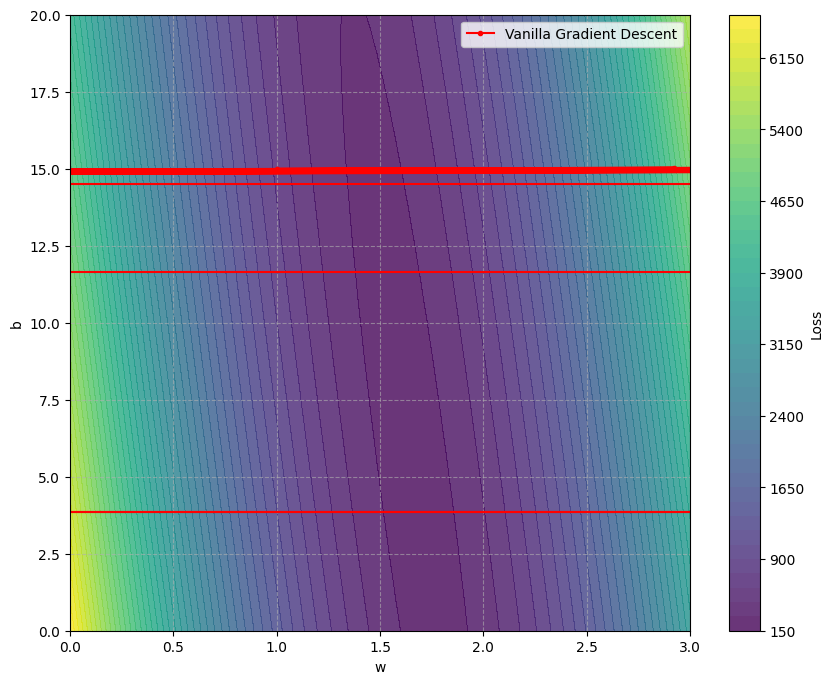

In [ ]:
# --- 訓練模型 ---

# 設定超參數 (Hyperparameters)
learning_rate = 0.001  # 學習率 (Learning Rate) 太小了嗎？但是再大就會炸裂了!
#學習率太大：步伐過大，可能一步就跨過山谷，跑到對面更高的山坡上，導致 Loss 不降反升，甚至發散。
#學習率太小：就像蝸牛在爬，雖然方向很穩，但走到谷底可能要天荒地老。
epochs = 100      # 訓練回合數

# 初始參數
w = 1
b = 15

# 用來記錄訓練過程的 list
w_history = []
b_history = []
loss_history = []
w_history.append(w)
b_history.append(b)
y_pred = linear_model(x1_train, w, b)
current_loss = mean_squared_error(y_pred, y_train)
loss_history.append(current_loss)

# 訓練迴圈開始
N = float(len(x1_train)) # 資料點的數量
for epoch in range(epochs):

    # 計算梯度 (偏微分的結果)
    y_pred = linear_model(x1_train, w, b)
    grad_w = (2/N) * np.sum((y_pred - y_train) * x1_train)
    grad_b = (2/N) * np.sum(y_pred - y_train)

    # 更新參數 (更新大小取決於學習率大小和梯度大小)
    w = w - learning_rate * grad_w
    b = b - learning_rate * grad_b

    # 記錄下目前的參數和 loss
    w_history.append(w)
    b_history.append(b)
    y_pred = linear_model(x1_train, w, b)
    current_loss = mean_squared_error(y_pred, y_train)
    loss_history.append(current_loss)

    # 印出目前狀況
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {current_loss:.4f}, w: {w:.4f}, b: {b:.4f}")

print("\n--- 訓練完成 ---")
print(f"最終訓練結果: w ≈ {w:.4f}, b ≈ {b:.4f}")

# --- 繪製 Loss Surface ---

# 建立範圍
w_range = np.linspace(0, 3, 100)
b_range = np.linspace(0, 20, 300)

w_range = np.linspace(0, 3, 100)
b_range = np.linspace(0, 20, 300)
W, B = np.meshgrid(w_range, b_range)

# 建立空的 Loss 矩陣
losses = np.zeros((len(b_range), len(w_range)))

# 逐一計算每個 (w, b) 的 loss
for i, b in enumerate(b_range):
    for j, w in enumerate(w_range):
        y_pred = linear_model(x1_train, w, b)
        loss = mean_squared_error(y_pred, y_train)
        losses[i, j] = loss

#在 Loss Surface 上畫出梯度下降的路徑
plt.figure(figsize=(10, 8))
contour = plt.contourf(W, B, losses, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Loss')
plt.plot(w_history, b_history, 'r-o', markersize=3, label='Vanilla Gradient Descent')
plt.xlabel('w')
plt.ylabel('b')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(w_range.min(), w_range.max())
plt.ylim(b_range.min(), b_range.max())
plt.show()

以 Adagrad 來訓練模型

Epoch [1/100], Loss: 886.9000, w: 2.0000, b: 16.0000
Epoch [2/100], Loss: 369.6754, w: 1.2399, b: 15.1700
Epoch [3/100], Loss: 277.6369, w: 1.5390, b: 15.3917
Epoch [4/100], Loss: 266.2778, w: 1.4382, b: 15.2140
Epoch [5/100], Loss: 264.6642, w: 1.4743, b: 15.1731
Epoch [6/100], Loss: 264.1738, w: 1.4640, b: 15.0871
Epoch [7/100], Loss: 263.8164, w: 1.4694, b: 15.0172
Epoch [8/100], Loss: 263.4793, w: 1.4695, b: 14.9429
Epoch [9/100], Loss: 263.1495, w: 1.4714, b: 14.8710
Epoch [10/100], Loss: 262.8253, w: 1.4726, b: 14.7992
Epoch [11/100], Loss: 262.5066, w: 1.4741, b: 14.7283
Epoch [12/100], Loss: 262.1931, w: 1.4754, b: 14.6580
Epoch [13/100], Loss: 261.8849, w: 1.4768, b: 14.5884
Epoch [14/100], Loss: 261.5817, w: 1.4782, b: 14.5194
Epoch [15/100], Loss: 261.2834, w: 1.4795, b: 14.4511
Epoch [16/100], Loss: 260.9900, w: 1.4808, b: 14.3835
Epoch [17/100], Loss: 260.7013, w: 1.4821, b: 14.3164
Epoch [18/100], Loss: 260.4173, w: 1.4834, b: 14.2500
Epoch [19/100], Loss: 260.1379, w: 1.

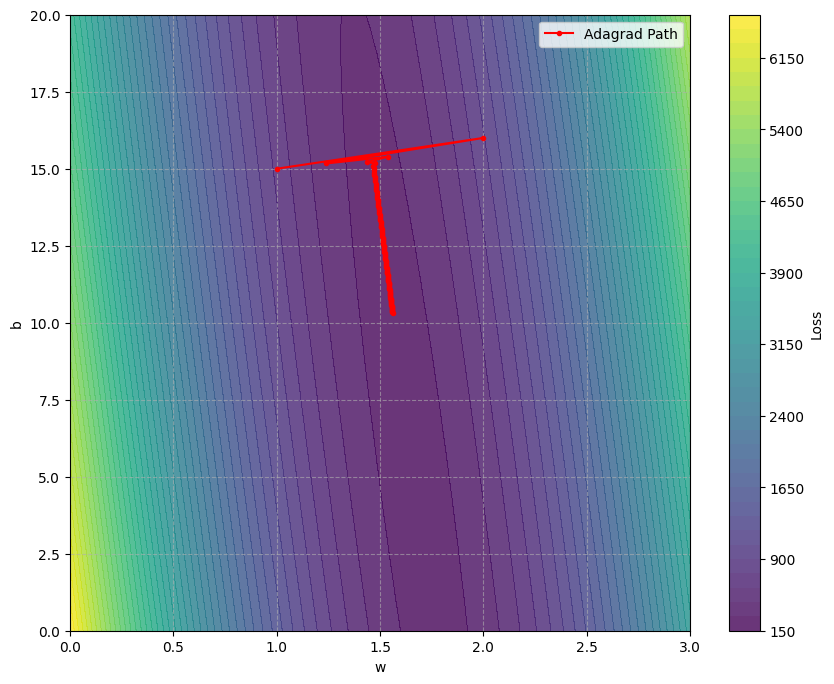

In [ ]:
# mean_squared_error 和 linear_model 的定義沿用前面的儲存格

# 定義 Adagrad 優化器
def adagrad_optimizer(w, b, grad_w, grad_b, grad_w_square, grad_b_square, learning_rate, epsilon=1e-8):
    """
    w, b: 當前參數
    grad_w, grad_b: 當前梯度
    grad_w_square, grad_b_square: 累積的平方梯度
    learning_rate: 學習率
    epsilon: 避免除以零的小數
    """
    # 累積平方梯度
    grad_w_square += grad_w**2
    grad_b_square += grad_b**2

    # 更新參數
    w -= learning_rate * grad_w / (np.sqrt(grad_w_square) + epsilon)
    b -= learning_rate * grad_b / (np.sqrt(grad_b_square) + epsilon)

    return w, b, grad_w_square, grad_b_square

# 設定超參數
learning_rate = 1  # Adagrad 的學習率通常可以設得比較大
epochs = 100

grad_w_square = 0
grad_b_square = 0

# 初始參數
w = 1
b = 15

# 用來記錄訓練過程的 list
w_history_adagrad = []
b_history_adagrad = []
loss_history_adagrad = []
w_history_adagrad.append(w)
b_history_adagrad.append(b)
y_pred = linear_model(x1_train, w, b)
current_loss = mean_squared_error(y_pred, y_train)
loss_history_adagrad.append(current_loss)

# 訓練迴圈開始
N = float(len(x1_train)) # 資料點的數量
for epoch in range(epochs):

    # 計算梯度 (偏微分的結果)
    y_pred = linear_model(x1_train, w, b)
    grad_w = (2/N) * np.sum((y_pred - y_train) * x1_train)
    grad_b = (2/N) * np.sum(y_pred - y_train)

    # 使用 Adagrad 更新參數
    w, b, grad_w_square, grad_b_square = adagrad_optimizer(w, b, grad_w, grad_b, grad_w_square, grad_b_square, learning_rate)

    # 記錄下目前的參數和 loss
    w_history_adagrad.append(w)
    b_history_adagrad.append(b)
    y_pred = linear_model(x1_train, w, b)
    current_loss = mean_squared_error(y_pred, y_train)
    loss_history_adagrad.append(current_loss)

    # 印出目前狀況
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {current_loss:.4f}, w: {w:.4f}, b: {b:.4f}")

print("\n--- 訓練完成 ---")
print(f"最終訓練結果: w ≈ {w:.4f}, b ≈ {b:.4f}")

# --- 繪製 Loss Surface 與 Adagrad 路徑 ---

plt.figure(figsize=(10, 8))
# 沿用前面儲存格計算的 Loss Surface 範圍和 Losses 矩陣
# w_range, b_range, losses

W, B = np.meshgrid(w_range, b_range)
contour = plt.contourf(W, B, losses, levels=50, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Loss')

# 繪製 Adagrad 的梯度下降路徑
plt.plot(w_history_adagrad, b_history_adagrad, 'r-o', markersize=3, label='Adagrad Path') # Adagrad 路徑

plt.xlabel('w')
plt.ylabel('b')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(w_range.min(), w_range.max())
plt.ylim(b_range.min(), b_range.max())
plt.show()

# 在香蕉函式 (Rosenbrock function) 上進行 Optimization

準備香蕉函式

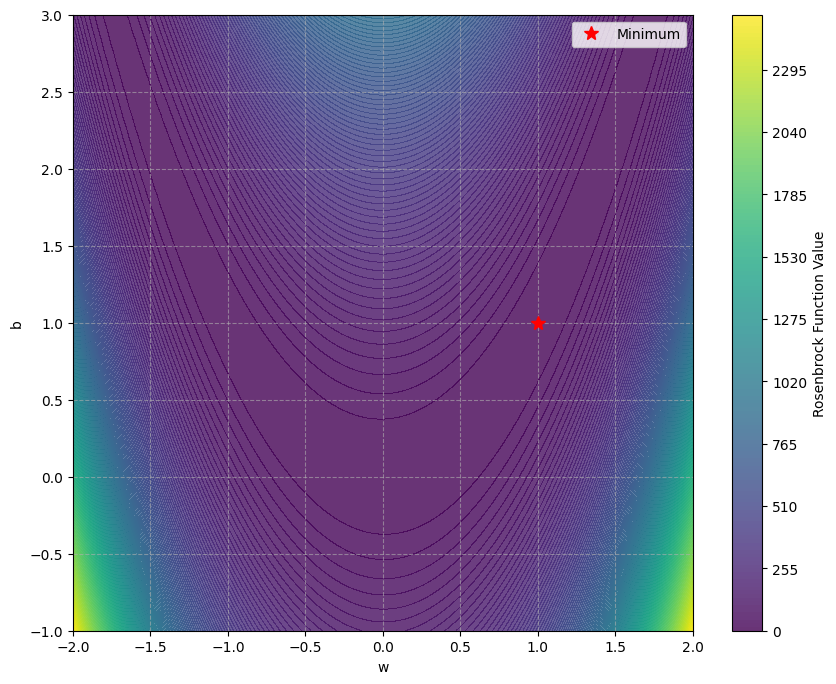

In [ ]:
# 以下自定義一個 Loss Surface
def rosenbrock_function(w, b):
    return (1 - w)**2 + 100 * (b - w**2)**2

def gradient_rosenbrock(w, b):
    grad_w = -2 * (1 - w) - 4 * 100 * w * (b - w**2)
    grad_b = 2 * 100 * (b - w**2)
    return grad_w, grad_b

# 建立 w 和 b 的範圍
w_range = np.linspace(-2, 2, 100)
b_range = np.linspace(-1, 3, 100)

# 建立網格
W, B = np.meshgrid(w_range, b_range)

# 計算對應的 Loss 值
losses = rosenbrock_function(W, B)

# 繪製等高線圖
plt.figure(figsize=(10, 8))
contour = plt.contourf(W, B, losses, levels=200, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Rosenbrock Function Value')

# 標出最小值 (1, 1)
plt.plot(1, 1, 'r*', markersize=10, label='Minimum')

# 設定標籤
plt.xlabel('w')
plt.ylabel('b')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend() # 顯示圖例以標示最小值

plt.show()

以 Adagrad 來訓練模型

Epoch [1/1000], Loss: 629.0000, w: -1.0000, b: 3.5000
Epoch [2/1000], Loss: 7.0862, w: -1.6368, b: 2.6425
Epoch [3/1000], Loss: 6.9896, w: -1.6181, b: 2.6550
Epoch [4/1000], Loss: 6.9374, w: -1.6300, b: 2.6424
Epoch [5/1000], Loss: 6.9115, w: -1.6206, b: 2.6474
Epoch [6/1000], Loss: 6.8969, w: -1.6260, b: 2.6402
Epoch [7/1000], Loss: 6.8881, w: -1.6211, b: 2.6414
Epoch [8/1000], Loss: 6.8820, w: -1.6233, b: 2.6368
Epoch [9/1000], Loss: 6.8773, w: -1.6207, b: 2.6362
Epoch [10/1000], Loss: 6.8731, w: -1.6213, b: 2.6329
Epoch [11/1000], Loss: 6.8693, w: -1.6197, b: 2.6315
Epoch [12/1000], Loss: 6.8656, w: -1.6197, b: 2.6287
Epoch [13/1000], Loss: 6.8620, w: -1.6186, b: 2.6269
Epoch [14/1000], Loss: 6.8584, w: -1.6182, b: 2.6244
Epoch [15/1000], Loss: 6.8548, w: -1.6173, b: 2.6224
Epoch [16/1000], Loss: 6.8512, w: -1.6167, b: 2.6201
Epoch [17/1000], Loss: 6.8476, w: -1.6160, b: 2.6179
Epoch [18/1000], Loss: 6.8440, w: -1.6153, b: 2.6157
Epoch [19/1000], Loss: 6.8405, w: -1.6146, b: 2.6135


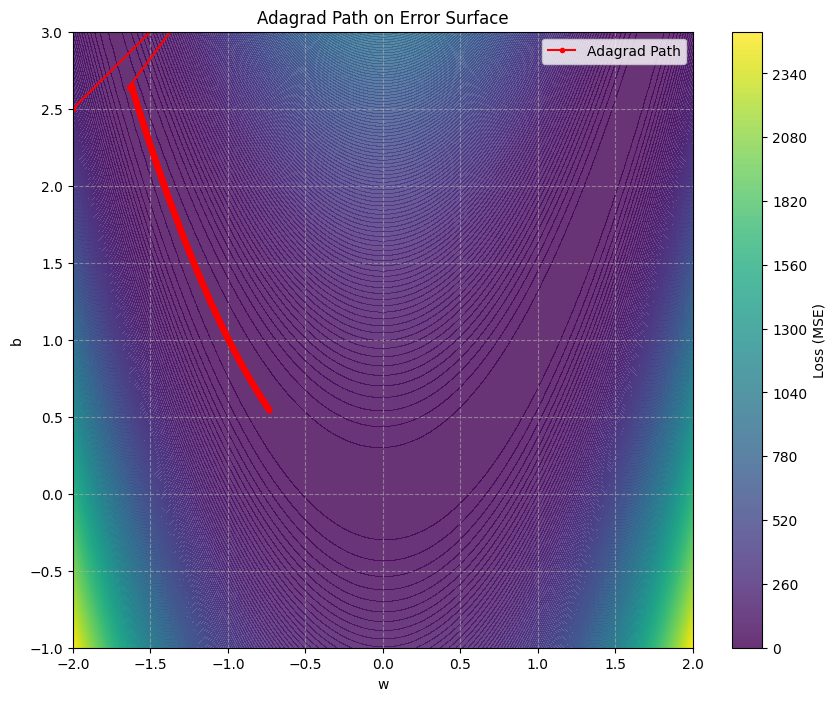

In [ ]:
# 定義 Adagrad 優化器
def adagrad_optimizer(w, b, grad_w, grad_b, grad_w_square, grad_b_square, learning_rate, epsilon=1e-8):
    """
    w, b: 當前參數
    grad_w, grad_b: 當前梯度
    grad_w_square, grad_b_square: 累積的平方梯度
    learning_rate: 學習率
    epsilon: 避免除以零的小數
    """
    # 累積平方梯度
    grad_w_square += grad_w**2
    grad_b_square += grad_b**2

    # 更新參數
    w -= learning_rate * grad_w / (np.sqrt(grad_w_square) + epsilon)
    b -= learning_rate * grad_b / (np.sqrt(grad_b_square) + epsilon)

    return w, b, grad_w_square, grad_b_square

# 設定超參數 (Hyperparameters)
learning_rate = 1  # Adagrad 的學習率通常可以設得比較大
epochs = 1000

grad_w_square = 0
grad_b_square = 0

# 初始參數
w = -2
b = 2.5

# 用來記錄訓練過程的 list
w_history_adagrad = []
b_history_adagrad = []
loss_history_adagrad = []
w_history_adagrad.append(w)
b_history_adagrad.append(b)
current_loss = rosenbrock_function(w, b)
loss_history_adagrad.append(current_loss)

# 訓練迴圈開始
N = float(len(x1_train)) # 資料點的數量
for epoch in range(epochs):

    # 計算梯度 (偏微分的結果)
    grad_w,grad_b = gradient_rosenbrock(w, b)

    # 使用 Adagrad 更新參數
    w, b, grad_w_square, grad_b_square = adagrad_optimizer(w, b, grad_w, grad_b, grad_w_square, grad_b_square, learning_rate)

    # 記錄下目前的參數和 loss
    w_history_adagrad.append(w)
    b_history_adagrad.append(b)
    current_loss = rosenbrock_function(w, b)
    loss_history_adagrad.append(current_loss)

    # 印出目前狀況
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {current_loss:.4f}, w: {w:.4f}, b: {b:.4f}")

print("\n--- Adagrad 訓練完成 ---")
print(f"最終訓練結果: w ≈ {w:.4f}, b ≈ {b:.4f}")

# --- 繪製 Loss Surface 與 Adagrad 路徑 ---

plt.figure(figsize=(10, 8))
# 沿用前面儲存格計算的 Loss Surface 範圍和 Losses 矩陣
# w_range, b_range, losses

W, B = np.meshgrid(w_range, b_range)
contour = plt.contourf(W, B, losses, levels=250, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Loss (MSE)')

# 繪製 Adagrad 的梯度下降路徑
plt.plot(w_history_adagrad, b_history_adagrad, 'r-o', markersize=3, label='Adagrad Path') # Adagrad 路徑

plt.xlabel('w')
plt.ylabel('b')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(w_range.min(), w_range.max())
plt.ylim(b_range.min(), b_range.max())
plt.title('Adagrad Path on Error Surface')
plt.show()

以 RMSProp 來訓練模型

Epoch [1/1000], Loss: 1858.8332, w: 1.1623, b: 5.6623
Epoch [2/1000], Loss: 15928.2165, w: 3.9085, b: 2.6593
Epoch [3/1000], Loss: 2566.4754, w: 0.7655, b: 5.6521
Epoch [4/1000], Loss: 1173.2004, w: 1.0252, b: 4.4763
Epoch [5/1000], Loss: 419.4019, w: 1.2722, b: 3.6662
Epoch [6/1000], Loss: 103.5207, w: 1.4649, b: 3.1623
Epoch [7/1000], Loss: 16.3923, w: 1.5808, b: 2.8996
Epoch [8/1000], Loss: 1.9653, w: 1.6326, b: 2.7904
Epoch [9/1000], Loss: 0.5251, w: 1.6500, b: 2.7545
Epoch [10/1000], Loss: 0.4338, w: 1.6545, b: 2.7448
Epoch [11/1000], Loss: 0.4300, w: 1.6554, b: 2.7425
Epoch [12/1000], Loss: 0.4298, w: 1.6554, b: 2.7418
Epoch [13/1000], Loss: 0.4296, w: 1.6553, b: 2.7413
Epoch [14/1000], Loss: 0.4294, w: 1.6552, b: 2.7408
Epoch [15/1000], Loss: 0.4292, w: 1.6550, b: 2.7403
Epoch [16/1000], Loss: 0.4290, w: 1.6549, b: 2.7398
Epoch [17/1000], Loss: 0.4288, w: 1.6547, b: 2.7393
Epoch [18/1000], Loss: 0.4286, w: 1.6545, b: 2.7387
Epoch [19/1000], Loss: 0.4283, w: 1.6544, b: 2.7381
Epo

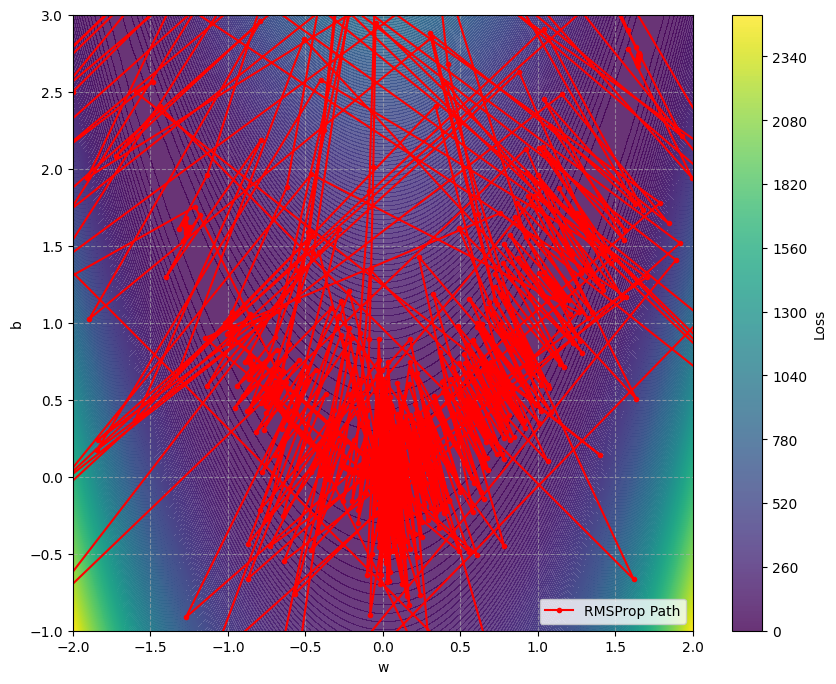

In [ ]:
# 定義 RMSProp 優化器
def rmsprop_optimizer(w, b, grad_w, grad_b, grad_w_square, grad_b_square, learning_rate, alpha, epsilon=1e-8):
    """
    w, b: 當前參數
    grad_w, grad_b: 當前梯度
    grad_w_square, grad_b_square: 累積的平方梯度
    learning_rate: 學習率
    epsilon: 避免除以零的小數
    """
    # 累積平方梯度
    grad_w_square = alpha*grad_w_square + (1-alpha)*grad_w**2
    grad_b_square = alpha*grad_b_square + (1-alpha)*grad_b**2

    # 更新參數
    w -= learning_rate * grad_w / (np.sqrt(grad_w_square) + epsilon)
    b -= learning_rate * grad_b / (np.sqrt(grad_b_square) + epsilon)

    return w, b, grad_w_square, grad_b_square

# 設定超參數 (Hyperparameters)
learning_rate = 1 #再設更大的話訓練會不穩定
epochs = 1000
alpha = 0.9 #新的梯度的權重為 1-alpha

grad_w_square = 0
grad_b_square = 0

# 初始參數
w = -2
b = 2.5

# 用來記錄訓練過程的 list
w_history_rmsprop = []
b_history_rmsprop = []
loss_history_rmsprop = []
w_history_rmsprop.append(w)
b_history_rmsprop.append(b)
current_loss = rosenbrock_function(w, b)
loss_history_rmsprop.append(current_loss)

# 訓練迴圈開始
N = float(len(x1_train)) # 資料點的數量
for epoch in range(epochs):

    # 計算梯度 (偏微分的結果)
    grad_w,grad_b = gradient_rosenbrock(w, b)

    # 使用 Adagrad 更新參數
    w, b, grad_w_square, grad_b_square = rmsprop_optimizer(w, b, grad_w, grad_b, grad_w_square, grad_b_square, learning_rate, alpha)

    # 記錄下目前的參數和 loss
    w_history_rmsprop.append(w)
    b_history_rmsprop.append(b)
    current_loss = rosenbrock_function(w, b)
    loss_history_rmsprop.append(current_loss)

    # 印出目前狀況
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {current_loss:.4f}, w: {w:.4f}, b: {b:.4f}")

print("\n--- RMSProp 訓練完成 ---")
print(f"最終訓練結果: w ≈ {w:.4f}, b ≈ {b:.4f}")

# --- 繪製 Loss Surface 與 RMSProp 路徑 ---

plt.figure(figsize=(10, 8))
# 沿用前面儲存格計算的 Loss Surface 範圍和 Losses 矩陣
# w_range, b_range, losses

W, B = np.meshgrid(w_range, b_range)
contour = plt.contourf(W, B, losses, levels=250, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Loss')

# 繪製梯度下降路徑
plt.plot(w_history_rmsprop, b_history_rmsprop, 'r-o', markersize=3, label='RMSProp Path') # Adagrad 路徑

plt.xlabel('w')
plt.ylabel('b')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(w_range.min(), w_range.max())
plt.ylim(b_range.min(), b_range.max())
plt.show()

#Rastrigin - 局部最小值陷阱

以 Rastrigin 函式作為最佳化的對象

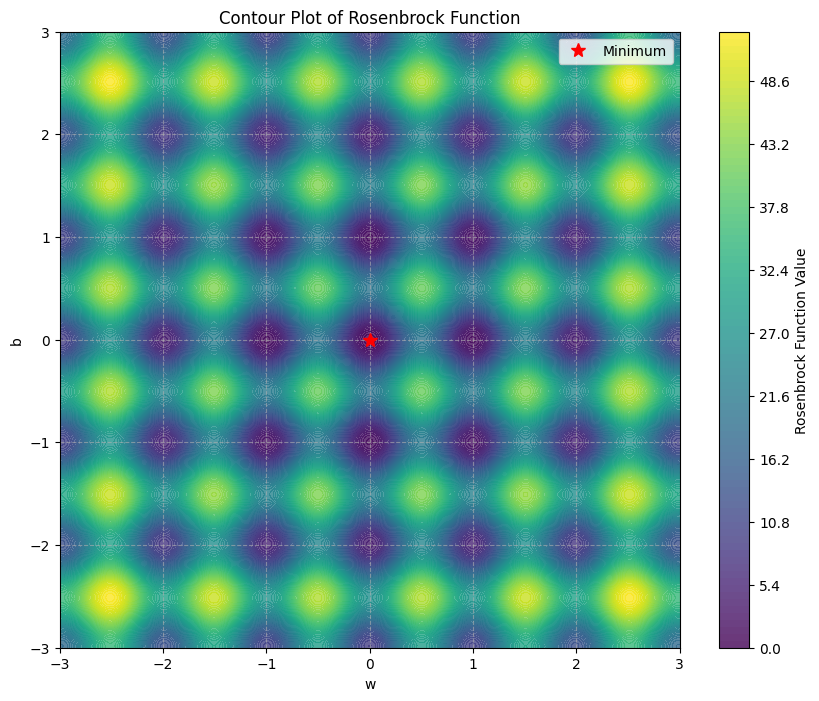

In [ ]:
# Rastrigin - 測試局部最小值陷阱
def rastrigin_function(w, b):
    return (w**2 - 10 * np.cos(2 * np.pi * w)) + \
           (b**2 - 10 * np.cos(2 * np.pi * b)) + 2 * 10

def gradient_rastrigin(w, b):
    grad_w = 2 * w + 2 * 10 * np.pi * np.sin(2 * np.pi * w)
    grad_b = 2 * b + 2 * 10 * np.pi * np.sin(2 * np.pi * b)
    return grad_w,grad_b

# 建立 w 和 b 的範圍
w_range = np.linspace(-3, 3, 300)
b_range = np.linspace(-3, 3, 300)

# 建立網格
W, B = np.meshgrid(w_range, b_range)

# 計算對應的 Loss 值
losses = rastrigin_function(W, B)

# 繪製等高線圖
plt.figure(figsize=(10, 8))
contour = plt.contourf(W, B, losses, levels=100, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Rosenbrock Function Value')

# 標出最小值 (0, 0)
plt.plot(0, 0, 'r*', markersize=10, label='Minimum')

# 設定標籤
plt.xlabel('w')
plt.ylabel('b')
plt.title('Contour Plot of Rosenbrock Function')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend() # 顯示圖例以標示最小值

plt.show()

以 RMSProp 來訓練模型

Epoch [1/1000], Loss: 51.7923, w: -2.4684, b: 2.4684
Epoch [2/1000], Loss: 50.3821, w: -2.4379, b: 2.4379
Epoch [3/1000], Loss: 48.5541, w: -2.4107, b: 2.4107
Epoch [4/1000], Loss: 46.5013, w: -2.3863, b: 2.3863
Epoch [5/1000], Loss: 44.3366, w: -2.3643, b: 2.3643
Epoch [6/1000], Loss: 42.1287, w: -2.3440, b: 2.3440
Epoch [7/1000], Loss: 39.9219, w: -2.3253, b: 2.3253
Epoch [8/1000], Loss: 37.7462, w: -2.3077, b: 2.3077
Epoch [9/1000], Loss: 35.6220, w: -2.2912, b: 2.2912
Epoch [10/1000], Loss: 33.5639, w: -2.2756, b: 2.2756
Epoch [11/1000], Loss: 31.5823, w: -2.2608, b: 2.2608
Epoch [12/1000], Loss: 29.6844, w: -2.2467, b: 2.2467
Epoch [13/1000], Loss: 27.8750, w: -2.2333, b: 2.2333
Epoch [14/1000], Loss: 26.1575, w: -2.2204, b: 2.2204
Epoch [15/1000], Loss: 24.5336, w: -2.2080, b: 2.2080
Epoch [16/1000], Loss: 23.0040, w: -2.1961, b: 2.1961
Epoch [17/1000], Loss: 21.5684, w: -2.1847, b: 2.1847
Epoch [18/1000], Loss: 20.2260, w: -2.1737, b: 2.1737
Epoch [19/1000], Loss: 18.9752, w: -2

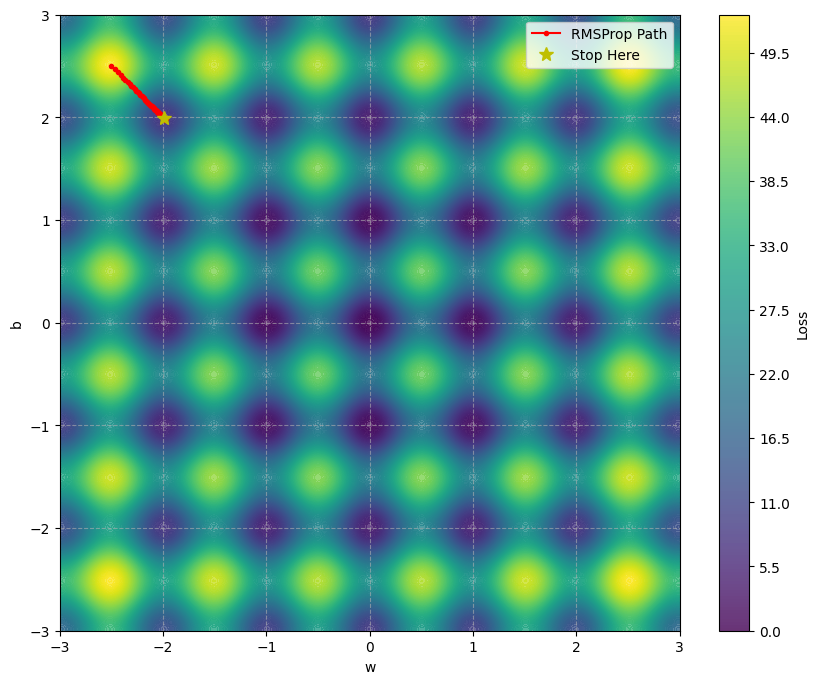

In [ ]:
# 設定超參數 (Hyperparameters)
learning_rate = 0.01
epochs = 1000
decay = 0.9

grad_w_square = 0
grad_b_square = 0

# 初始參數
w = -2.5
b = 2.5

# 用來記錄訓練過程的 list
w_history_rmsprop = []
b_history_rmsprop = []
loss_history_rmsprop = []
w_history_rmsprop.append(w)
b_history_rmsprop.append(b)
current_loss = rastrigin_function(w, b)
loss_history_rmsprop.append(current_loss)

# 訓練迴圈開始
N = float(len(x1_train)) # 資料點的數量
for epoch in range(epochs):

    # 計算梯度 (偏微分的結果)
    grad_w,grad_b = gradient_rastrigin(w, b)

    # 使用 Adagrad 更新參數
    w, b, grad_w_square, grad_b_square = rmsprop_optimizer(w, b, grad_w, grad_b, grad_w_square, grad_b_square, learning_rate, decay)

    # 記錄下目前的參數和 loss
    w_history_rmsprop.append(w)
    b_history_rmsprop.append(b)
    current_loss = rastrigin_function(w, b)
    loss_history_rmsprop.append(current_loss)

    # 印出目前狀況
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {current_loss:.4f}, w: {w:.4f}, b: {b:.4f}")

print("\n--- RMSProp 訓練完成 ---")
print(f"最終訓練結果: w ≈ {w:.4f}, b ≈ {b:.4f}")

# --- 繪製 Loss Surface 與 Adagrad 路徑 ---

plt.figure(figsize=(10, 8))
# 沿用前面儲存格計算的 Loss Surface 範圍和 Losses 矩陣
# w_range, b_range, losses

W, B = np.meshgrid(w_range, b_range)
contour = plt.contourf(W, B, losses, levels=250, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Loss')

# 繪製梯度下降路徑
plt.plot(w_history_rmsprop, b_history_rmsprop, 'r-o', markersize=3, label='RMSProp Path') # Adagrad 路徑

plt.plot(w, b, 'y*', markersize=10, label='Stop Here')

plt.xlabel('w')
plt.ylabel('b')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(w_range.min(), w_range.max())
plt.ylim(b_range.min(), b_range.max())
plt.show()

以 Momentum 來訓練模型

Epoch [1/1000], Loss: 52.4975, w: -2.4998, b: 2.4998
Epoch [2/1000], Loss: 52.4922, w: -2.4992, b: 2.4992
Epoch [3/1000], Loss: 52.4839, w: -2.4985, b: 2.4985
Epoch [4/1000], Loss: 52.4718, w: -2.4974, b: 2.4974
Epoch [5/1000], Loss: 52.4550, w: -2.4961, b: 2.4961
Epoch [6/1000], Loss: 52.4323, w: -2.4944, b: 2.4944
Epoch [7/1000], Loss: 52.4019, w: -2.4924, b: 2.4924
Epoch [8/1000], Loss: 52.3615, w: -2.4900, b: 2.4900
Epoch [9/1000], Loss: 52.3079, w: -2.4872, b: 2.4872
Epoch [10/1000], Loss: 52.2371, w: -2.4839, b: 2.4839
Epoch [11/1000], Loss: 52.1438, w: -2.4800, b: 2.4800
Epoch [12/1000], Loss: 52.0209, w: -2.4755, b: 2.4755
Epoch [13/1000], Loss: 51.8591, w: -2.4703, b: 2.4703
Epoch [14/1000], Loss: 51.6465, w: -2.4644, b: 2.4644
Epoch [15/1000], Loss: 51.3672, w: -2.4574, b: 2.4574
Epoch [16/1000], Loss: 51.0012, w: -2.4495, b: 2.4495
Epoch [17/1000], Loss: 50.5224, w: -2.4404, b: 2.4404
Epoch [18/1000], Loss: 49.8978, w: -2.4299, b: 2.4299
Epoch [19/1000], Loss: 49.0863, w: -2

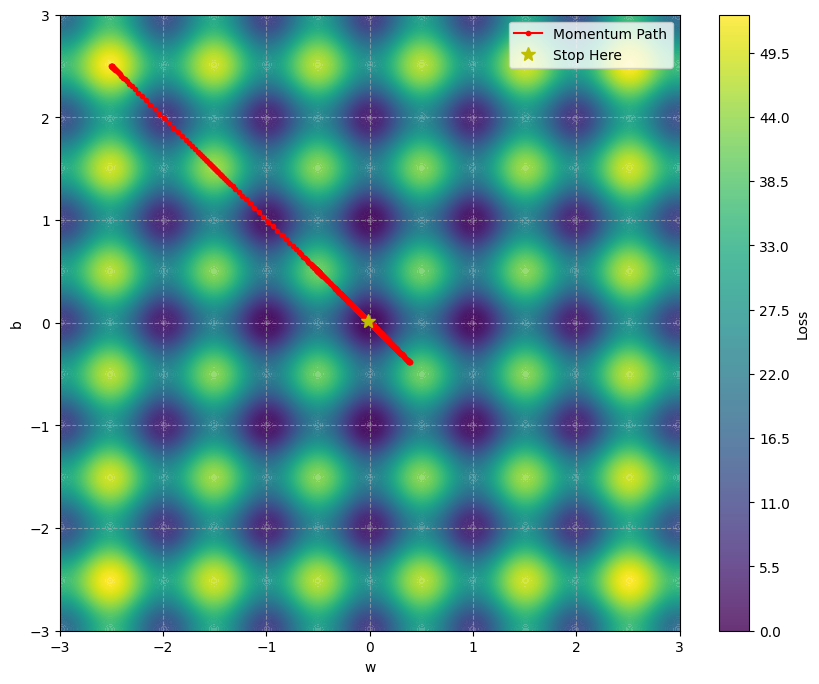

In [ ]:
def momentum_optimizer(w, b, grad_w, grad_b, momentum_w, momentum_b, learning_rate, beta):
    """
    w, b: 當前參數
    grad_w, grad_b: 當前梯度
    momentum: 動量
    learning_rate: 學習率
    """
    # 累積動量
    momentum_w = beta * momentum_w + (1-beta)*grad_w
    momentum_b = beta * momentum_b + (1-beta)*grad_b

    # 更新參數
    w -= learning_rate * momentum_w
    b -= learning_rate * momentum_b

    return w, b, momentum_w, momentum_b

# 設定超參數 (Hyperparameters)
learning_rate = 0.01
epochs = 1000
beta = 0.995 #新的梯度的權重是 1-beta

momentum_w = 0
momentum_b = 0

# 初始參數
w = -2.5
b = 2.5

# 用來記錄訓練過程的 list
w_history_momentum = []
b_history_momentum = []
loss_history_momentum = []
w_history_momentum.append(w)
b_history_momentum.append(b)
current_loss = rastrigin_function(w, b)
loss_history_momentum.append(current_loss)

# 訓練迴圈開始
for epoch in range(epochs):

    # 計算梯度 (偏微分的結果)
    grad_w,grad_b = gradient_rastrigin(w, b)

    # 使用 momentum 更新參數
    w, b, momentum_w, momentum_b = momentum_optimizer(w, b, grad_w, grad_b, momentum_w, momentum_b, learning_rate, beta)

    # 記錄下目前的參數和 loss
    w_history_momentum.append(w)
    b_history_momentum.append(b)
    current_loss = rastrigin_function(w, b)
    loss_history_momentum.append(current_loss)

    # 印出目前狀況
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {current_loss:.4f}, w: {w:.4f}, b: {b:.4f}")

print("\n--- Momentum 訓練完成 ---")
print(f"最終訓練結果: w ≈ {w:.4f}, b ≈ {b:.4f}")

# --- 繪製 Loss Surface 與 Momentum 路徑 ---

plt.figure(figsize=(10, 8))
# 沿用前面儲存格計算的 Loss Surface 範圍和 Losses 矩陣
# w_range, b_range, losses

W, B = np.meshgrid(w_range, b_range)
contour = plt.contourf(W, B, losses, levels=250, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Loss')

# 繪製梯度下降路徑
plt.plot(w_history_momentum, b_history_momentum, 'r-o', markersize=3, label='Momentum Path')


plt.plot(w, b, 'y*', markersize=10, label='Stop Here')

plt.xlabel('w')
plt.ylabel('b')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(w_range.min(), w_range.max())
plt.ylim(b_range.min(), b_range.max())
plt.show()

# 換回香蕉函式

In [ ]:
# 以下自定義一個 Loss Surface
def rosenbrock_function(w, b):
    return (1 - w)**2 + 100 * (b - w**2)**2

def gradient_rosenbrock(w, b):
    grad_w = -2 * (1 - w) - 4 * 100 * w * (b - w**2)
    grad_b = 2 * 100 * (b - w**2)
    return grad_w, grad_b

# 建立 w 和 b 的範圍
w_range = np.linspace(-2, 2, 100)
b_range = np.linspace(-1, 3, 100)

# 建立網格
W, B = np.meshgrid(w_range, b_range)

# 計算對應的 Loss 值
losses = rosenbrock_function(W, B)

以 Adam 進行訓練

Epoch [1/1000], Loss: 402.6854, w: -1.9968, b: 2.0032
Epoch [2/1000], Loss: 394.0763, w: -1.9925, b: 2.0075
Epoch [3/1000], Loss: 383.9381, w: -1.9873, b: 2.0127
Epoch [4/1000], Loss: 372.7038, w: -1.9814, b: 2.0186
Epoch [5/1000], Loss: 360.6691, w: -1.9750, b: 2.0250
Epoch [6/1000], Loss: 348.0537, w: -1.9682, b: 2.0318
Epoch [7/1000], Loss: 335.0294, w: -1.9610, b: 2.0391
Epoch [8/1000], Loss: 321.7346, w: -1.9534, b: 2.0466
Epoch [9/1000], Loss: 308.2826, w: -1.9456, b: 2.0544
Epoch [10/1000], Loss: 294.7675, w: -1.9375, b: 2.0625
Epoch [11/1000], Loss: 281.2685, w: -1.9293, b: 2.0707
Epoch [12/1000], Loss: 267.8521, w: -1.9208, b: 2.0792
Epoch [13/1000], Loss: 254.5747, w: -1.9122, b: 2.0878
Epoch [14/1000], Loss: 241.4841, w: -1.9035, b: 2.0966
Epoch [15/1000], Loss: 228.6208, w: -1.8946, b: 2.1055
Epoch [16/1000], Loss: 216.0193, w: -1.8856, b: 2.1144
Epoch [17/1000], Loss: 203.7086, w: -1.8766, b: 2.1235
Epoch [18/1000], Loss: 191.7131, w: -1.8674, b: 2.1327
Epoch [19/1000], Lo

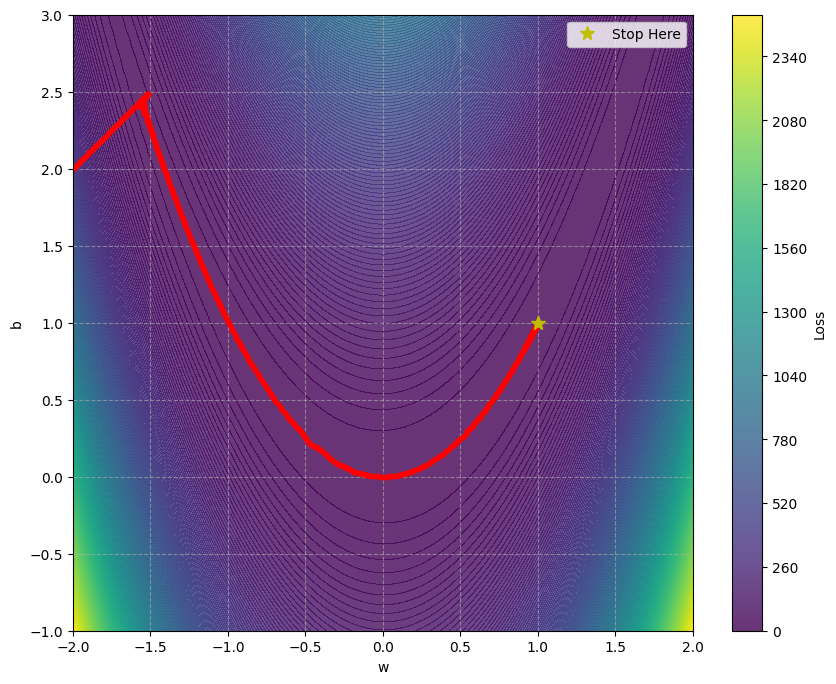

In [ ]:
#注意：此處實作的並非正版 Adam ，而是簡化過的版本
def adam_optimizer(w, b, grad_w, grad_b, grad_w_square, grad_b_square,  momentum_w, momentum_b, learning_rate, alpha, beta, epsilon=1e-8):
    """
    w, b: 當前參數
    grad_w, grad_b: 當前梯度
    grad_w_square, grad_b_square: 累積的平方梯度
    momentum_w, momentum_b: 動量
    learning_rate: 學習率
    """
    t = epoch +1

    # 累積平方梯度
    grad_w_square = alpha*grad_w_square + (1-alpha)*grad_w**2
    grad_b_square = alpha*grad_b_square + (1-alpha)*grad_b**2

    # 累積動量
    momentum_w = beta * momentum_w + (1-beta)*grad_w
    momentum_b = beta * momentum_b + (1-beta)*grad_b

    # 更新參數
    w -= learning_rate * momentum_w / (np.sqrt(grad_w_square) + epsilon)
    b -= learning_rate * momentum_b / (np.sqrt(grad_b_square) + epsilon)

    return w, b,  grad_w_square, grad_b_square, momentum_w, momentum_b

# 設定超參數 (Hyperparameters)
learning_rate = 0.01
epochs = 1000
alpha = 0.9
beta = 0.9

grad_w_square = 0
grad_b_square = 0
momentum_w = 0
momentum_b = 0

# 初始參數
w = -2
b = 2

# 用來記錄訓練過程的 list
w_history_adam = []
b_history_adam = []
loss_history_adam = []
w_history_adam.append(w)
b_history_adam.append(b)
current_loss = rosenbrock_function(w, b)
loss_history_adam.append(current_loss)

# 訓練迴圈開始
for epoch in range(epochs):

    # 計算梯度 (偏微分的結果)
    grad_w,grad_b = gradient_rosenbrock(w, b)

    # 使用 momentum 更新參數
    w, b,  grad_w_square, grad_b_square,momentum_w, momentum_b = \
     adam_optimizer(w, b, grad_w, grad_b,  grad_w_square, grad_b_square,momentum_w, momentum_b, learning_rate, alpha, beta)

    # 記錄下目前的參數和 loss
    w_history_adam.append(w)
    b_history_adam.append(b)
    current_loss = rosenbrock_function(w, b)
    loss_history_adam.append(current_loss)

    # 印出目前狀況
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {current_loss:.4f}, w: {w:.4f}, b: {b:.4f}")

print("\n--- 訓練完成 ---")
print(f"最終訓練結果: w ≈ {w:.4f}, b ≈ {b:.4f}")

# --- 繪製 Loss Surface 與 Adam 路徑 ---

plt.figure(figsize=(10, 8))
# 沿用前面儲存格計算的 Loss Surface 範圍和 Losses 矩陣
# w_range, b_range, losses

W, B = np.meshgrid(w_range, b_range)
contour = plt.contourf(W, B, losses, levels=250, cmap='viridis', alpha=0.8)
plt.colorbar(contour, label='Loss')

# 繪製梯度下降路徑
plt.plot(w_history_adam, b_history_adam, 'r-o', markersize=3)

plt.plot(w, b, 'y*', markersize=10, label='Stop Here')

plt.xlabel('w')
plt.ylabel('b')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(w_range.min(), w_range.max())
plt.ylim(b_range.min(), b_range.max())
plt.show()

### 以《生成式AI導論 2024》資料進行訓練

In [ ]:
#訓練資料
x1_train = page_2024
x2_train = word_2024/page_2024 #平均字數
y_train = duration_2024

In [ ]:
# 訓練類神經網路

def relu(x):
    return np.maximum(0, x)

def nn_forward(X, W, b, Wp, bp):
    """
    X:  (2, N)
    W:  (H, 2)
    b:  (H, 1)
    Wp: (1, H)
    bp: (1, 1)
    A: (H,N)
    Z: (H,N)
    回傳:
      y_pred: (1, N)
      cache:  訓練時需要的中間值
    """
    Z = W @ X + b        # (H, N)
    A = relu(Z)          # (H, N)
    y_pred = Wp @ A + bp    # (1, N)
    cache = (X, Z, A)
    return y_pred, cache

def relu_grad(x):
    return (x > 0)

def nn_backward(dy, cache, W, b, Wp, bp):
    """
    dy:     (1, N) = dL/d(y_pred)
    cache:  (X, Z, A)
    回傳:   dW, db, dWp, dbp 與各自形狀相同
    """
    X, Z, A = cache
    # 輸出層：y = Wp @ A + bp
    dWp = dy @ A.T                  # (1, N) @ (N, H) = (1, H)
    dbp = dy.sum(axis=1, keepdims=True)  # (1, 1)
    dA  = Wp.T @ dy                 # (H, 1) @ (1, N) = (H, N)

    # 隱藏層：A = ReLU(Z)
    dZ = dA * relu_grad(Z)          # (H, N)

    # 第一層：Z = W @ X + b
    dW = dZ @ X.T                   # (H, N) @ (N, 2) = (H, 2)
    db = dZ.sum(axis=1, keepdims=True)   # (H, 1)

    return dW, db, dWp, dbp

In [ ]:
H = 100            # 隱藏層大小，可自行調整
in_dim = 2        # 輸入維度 x1, x2
out_dim = 1       # 輸出維度

# 刻意不固定隨機種子，顯示初始對於結果的影響
W = np.random.randn(H, in_dim)
b = np.random.randn(H,1)
Wp = np.random.randn(out_dim, H)
bp = np.random.randn(out_dim,1)

# === Adam 參數 ===
learning_rate_nn = 0.01
epochs_nn = 10000
beta1 = 0.9
beta2 = 0.999
eps = 1e-8

loss_history = []

N_train = float(len(x1_train))

# 初始化 Adam 的一階與二階動量
mW = np.zeros_like(W)
mb = np.zeros_like(b)
mWp = np.zeros_like(Wp)
mbp = np.zeros_like(bp)

vW = np.zeros_like(W)
vb = np.zeros_like(b)
vWp = np.zeros_like(Wp)
vbp = np.zeros_like(bp)

for epoch in range(1, epochs_nn + 1):

    # forward
    X = np.vstack((x1_train, x2_train))
    y_pred, cache = nn_forward(X, W, b, Wp, bp)
    dy = (2.0 / N_train) * (y_pred - y_train)

    # backward
    dW, db, dWp, dbp = nn_backward(dy, cache, W, b, Wp, bp)

    # === Adam 更新 ===
    # 更新一階動量 (m)
    mW = beta1 * mW + (1 - beta1) * dW
    mb = beta1 * mb + (1 - beta1) * db
    mWp = beta1 * mWp + (1 - beta1) * dWp
    mbp = beta1 * mbp + (1 - beta1) * dbp

    # 更新二階動量 (v)
    vW = beta2 * vW + (1 - beta2) * (dW ** 2)
    vb = beta2 * vb + (1 - beta2) * (db ** 2)
    vWp = beta2 * vWp + (1 - beta2) * (dWp ** 2)
    vbp = beta2 * vbp + (1 - beta2) * (dbp ** 2)

    # 偏差修正 (bias correction)
    mW_hat = mW / (1 - beta1 ** epoch)
    mb_hat = mb / (1 - beta1 ** epoch)
    mWp_hat = mWp / (1 - beta1 ** epoch)
    mbp_hat = mbp / (1 - beta1 ** epoch)

    vW_hat = vW / (1 - beta2 ** epoch)
    vb_hat = vb / (1 - beta2 ** epoch)
    vWp_hat = vWp / (1 - beta2 ** epoch)
    vbp_hat = vbp / (1 - beta2 ** epoch)

    # 更新參數
    W  -= learning_rate_nn * mW_hat / (np.sqrt(vW_hat) + eps)
    b  -= learning_rate_nn * mb_hat / (np.sqrt(vb_hat) + eps)
    Wp -= learning_rate_nn * mWp_hat / (np.sqrt(vWp_hat) + eps)
    bp -= learning_rate_nn * mbp_hat / (np.sqrt(vbp_hat) + eps)

    # 計算 Loss
    y_pred, cache = nn_forward(X, W, b, Wp, bp)
    loss = mean_squared_error(y_pred, y_train)
    loss_history.append(loss)

    print(f"Epoch [{epoch}/{epochs_nn}], Loss: {loss:.6f}")

串流輸出內容已截斷至最後 5000 行。
Epoch [5001/10000], Loss: 17.016461
Epoch [5002/10000], Loss: 17.014057
Epoch [5003/10000], Loss: 17.011333
Epoch [5004/10000], Loss: 17.009197
Epoch [5005/10000], Loss: 17.005987
Epoch [5006/10000], Loss: 17.002901
Epoch [5007/10000], Loss: 16.999969
Epoch [5008/10000], Loss: 17.001197
Epoch [5009/10000], Loss: 16.995971
Epoch [5010/10000], Loss: 16.992737
Epoch [5011/10000], Loss: 16.990939
Epoch [5012/10000], Loss: 16.988073
Epoch [5013/10000], Loss: 16.985709
Epoch [5014/10000], Loss: 16.986375
Epoch [5015/10000], Loss: 16.981605
Epoch [5016/10000], Loss: 16.978353
Epoch [5017/10000], Loss: 16.976556
Epoch [5018/10000], Loss: 16.973867
Epoch [5019/10000], Loss: 16.970132
Epoch [5020/10000], Loss: 16.967421
Epoch [5021/10000], Loss: 16.963751
Epoch [5022/10000], Loss: 16.961015
Epoch [5023/10000], Loss: 16.959054
Epoch [5024/10000], Loss: 16.956441
Epoch [5025/10000], Loss: 16.953891
Epoch [5026/10000], Loss: 16.952539
Epoch [5027/10000], Loss: 16.948732
Epoch [

In [ ]:
H = 100            # 隱藏層大小，可自行調整
in_dim = 2        # 輸入維度 x1, x2
out_dim = 1       # 輸出維度

#原來的 initializaation 方式
#W = np.random.randn(H, in_dim)
#b = np.random.randn(H,1)
#Wp = np.random.randn(out_dim, H)
#bp = np.random.randn(out_dim,1)

# 改變初始化隨機取樣的方法
# 刻意不固定隨機種子，顯示初始對於結果的影響
# --- 第一層（ReLU 前） --- # Kaiming Initialization: https://arxiv.org/abs/1502.01852
W = np.random.randn(H, in_dim) * np.sqrt(2.0 / in_dim)
b = np.random.randn(H,1)
# --- 第二層（輸出層）  ---
Wp = np.random.randn(out_dim, H) * np.sqrt(1.0 / H)
bp = np.random.randn(out_dim,1)

# === Adam 參數 ===
learning_rate_nn = 0.01
epochs_nn = 10000
beta1 = 0.9
beta2 = 0.999
eps = 1e-8

loss_history = []

N_train = float(len(x1_train))

# 初始化 Adam 的一階與二階動量
mW = np.zeros_like(W)
mb = np.zeros_like(b)
mWp = np.zeros_like(Wp)
mbp = np.zeros_like(bp)

vW = np.zeros_like(W)
vb = np.zeros_like(b)
vWp = np.zeros_like(Wp)
vbp = np.zeros_like(bp)

for epoch in range(1, epochs_nn + 1):

    # forward
    X = np.vstack((x1_train, x2_train))
    y_pred, cache = nn_forward(X, W, b, Wp, bp)
    dy = (2.0 / N_train) * (y_pred - y_train)

    # backward
    dW, db, dWp, dbp = nn_backward(dy, cache, W, b, Wp, bp)

    # === Adam 更新 ===
    # 更新一階動量 (m)
    mW = beta1 * mW + (1 - beta1) * dW
    mb = beta1 * mb + (1 - beta1) * db
    mWp = beta1 * mWp + (1 - beta1) * dWp
    mbp = beta1 * mbp + (1 - beta1) * dbp

    # 更新二階動量 (v)
    vW = beta2 * vW + (1 - beta2) * (dW ** 2)
    vb = beta2 * vb + (1 - beta2) * (db ** 2)
    vWp = beta2 * vWp + (1 - beta2) * (dWp ** 2)
    vbp = beta2 * vbp + (1 - beta2) * (dbp ** 2)

    # 偏差修正 (bias correction)
    mW_hat = mW / (1 - beta1 ** epoch)
    mb_hat = mb / (1 - beta1 ** epoch)
    mWp_hat = mWp / (1 - beta1 ** epoch)
    mbp_hat = mbp / (1 - beta1 ** epoch)

    vW_hat = vW / (1 - beta2 ** epoch)
    vb_hat = vb / (1 - beta2 ** epoch)
    vWp_hat = vWp / (1 - beta2 ** epoch)
    vbp_hat = vbp / (1 - beta2 ** epoch)

    # 更新參數
    W  -= learning_rate_nn * mW_hat / (np.sqrt(vW_hat) + eps)
    b  -= learning_rate_nn * mb_hat / (np.sqrt(vb_hat) + eps)
    Wp -= learning_rate_nn * mWp_hat / (np.sqrt(vWp_hat) + eps)
    bp -= learning_rate_nn * mbp_hat / (np.sqrt(vbp_hat) + eps)

    # 計算 Loss
    y_pred, cache = nn_forward(X, W, b, Wp, bp)
    loss = mean_squared_error(y_pred, y_train)
    loss_history.append(loss)

    print(f"Epoch [{epoch}/{epochs_nn}], Loss: {loss:.6f}")

串流輸出內容已截斷至最後 5000 行。
Epoch [5001/10000], Loss: 2.099638
Epoch [5002/10000], Loss: 2.198064
Epoch [5003/10000], Loss: 2.161579
Epoch [5004/10000], Loss: 2.032629
Epoch [5005/10000], Loss: 1.845160
Epoch [5006/10000], Loss: 1.662702
Epoch [5007/10000], Loss: 1.602388
Epoch [5008/10000], Loss: 1.567889
Epoch [5009/10000], Loss: 1.554978
Epoch [5010/10000], Loss: 1.570724
Epoch [5011/10000], Loss: 1.604032
Epoch [5012/10000], Loss: 1.638907
Epoch [5013/10000], Loss: 1.625132
Epoch [5014/10000], Loss: 1.615662
Epoch [5015/10000], Loss: 1.585271
Epoch [5016/10000], Loss: 1.575674
Epoch [5017/10000], Loss: 1.556184
Epoch [5018/10000], Loss: 1.530695
Epoch [5019/10000], Loss: 1.533238
Epoch [5020/10000], Loss: 1.534142
Epoch [5021/10000], Loss: 1.535750
Epoch [5022/10000], Loss: 1.529707
Epoch [5023/10000], Loss: 1.536458
Epoch [5024/10000], Loss: 1.568145
Epoch [5025/10000], Loss: 1.612604
Epoch [5026/10000], Loss: 1.694259
Epoch [5027/10000], Loss: 1.806547
Epoch [5028/10000], Loss: 1.973633